# CDT 1-D CNN + макро-признаки
Расширение лучшей модели (CDT 1-D CNN w/o TIs, AAR +9.2%) макроэкономическими данными.

**Новые признаки:**
| Признак | Источник | Частота | Что даёт модели |
|---|---|---|---|
| MOEX Close | MOEX_1day.parquet | дневная → 5мин | Режим рынка (бычий/медвежий) |
| MOEX Volatility | rolling std(MOEX) | дневная → 5мин | Уровень стресса на рынке |
| Relative Strength | ticker / MOEX | дневная → 5мин | Сила актива vs рынок |
| Ключевая ставка | market_context | годовая → 5мин | Монетарная политика ЦБ |
| Инфляция | market_context | годовая → 5мин | Макро-режим |

## 1. Импорты и GPU

In [ ]:
# === 1. Подключение Google Диска ===
from google.colab import drive
import os

drive.mount('/content/drive')

# Укажите путь к вашей папке проекта на Диске
PROJECT_DIR = '/content/drive/MyDrive/CDT_Project'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

# Создаем папку для результатов, если её нет
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Диск подключен!")
print(f"Данные будут браться из: {DATA_DIR}")
print(f"Результаты будут сохраняться в: {RESULTS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Диск подключен!
Данные будут браться из: /content/drive/MyDrive/CDT_Project/data
Результаты будут сохраняться в: /content/drive/MyDrive/CDT_Project/results


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from sklearn.utils.class_weight import compute_class_weight
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

## 2. Параметры

In [ ]:
WINDOW_SIZE = 24
ALPHA = 1
TRAIN_MONTHS = 48
TEST_MONTHS = 1
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.3
L2_DECAY = 1e-5
BATCH_SIZE = 32
EPOCHS = 30
CONFIDENCE_THRESHOLD = 0.50
BETA1, BETA2, BETA3 = 0.5, 0.125, 0.125

TICKERS = ['SBER', 'MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']
# TICKERS = ['SBER', 'LKOH', 'YDEX', 'GLDRUB_TOM']

## 3. Базовые функции (предобработка, разметка, тензоры, модели)

In [ ]:
def clean_market_data(df):
    df = df.copy()
    # Векторизованная замена нулей (быстрее чем .replace)
    for col in ['Open', 'High', 'Low', 'Close']:
        arr = df[col].values.copy()
        arr[arr == 0] = np.nan
        df[col] = arr

    df = df.sort_values("DateTime")
    # Один ffill и один bfill вместо вызова на каждом столбце
    df[['Open','High','Low','Close']] = df[['Open','High','Low','Close']].ffill().bfill()
    df['Volume'] = df['Volume'].fillna(0)
    return df

def fill_time_gaps(df, interval_name="5min"):
    freq_map = {"5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"}
    df = df.copy()
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime').sort_index()

    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq_map.get(interval_name, "5min"))
    df = df.reindex(full_range)
    df.index.name = 'DateTime'

    df['Close'] = df['Close'].ffill()
    # Быстрая векторизованная замена NaN в O, H, L на Close
    for col in ['Open', 'High', 'Low']:
        mask = df[col].isna()
        df.loc[mask, col] = df.loc[mask, 'Close']

    df['Volume'] = df['Volume'].fillna(0)
    return df.reset_index()

def create_labels(df, alpha=ALPHA, window_size=WINDOW_SIZE):
    close = df['Close'].values.astype(np.float64)
    # Используем pandas только для быстрого rolling std
    vol = pd.Series(close).pct_change().rolling(10).std().values

    # Векторизованный расчет будущей доходности (без создания лишних Series)
    future = np.empty_like(close)
    future[:-window_size] = (close[window_size:] - close[:-window_size]) / close[:-window_size]
    future[-window_size:] = np.nan

    valid = ~np.isnan(vol) & ~np.isnan(future) & (vol > 0)
    labels = np.where(valid & (future >= alpha * vol), 1,
             np.where(valid & (future <= -alpha * vol), 2, 0))
    return labels

def create_tensors(df, feature_cols, window_size=WINDOW_SIZE, alpha=ALPHA):
    df = df.copy().sort_values("DateTime").reset_index(drop=True)
    df['Target'] = create_labels(df, alpha=alpha, window_size=window_size)

    # Быстрая зачистка Inf и NaN
    data_x = df[feature_cols].values.astype(np.float32)
    data_x[~np.isfinite(data_x)] = np.nan
    # Быстрыйfillna по столбцам с помощью numpy
    col_means = np.nanmean(data_x, axis=0)
    nan_mask = np.isnan(data_x)
    for i in range(data_x.shape[1]):
        data_x[nan_mask[:, i], i] = col_means[i]

    # ГЛОБАЛЬНАЯ НОРМАЛИЗАЦИЯ (Z-score по всему датасету)
    # Это в 100 раз быстрее, чем считать mean/std для каждого окна отдельно.
    # И это стандартная практика для нейросетей.
    m_global = data_x.mean(axis=0, keepdims=True)
    s_global = data_x.std(axis=0, keepdims=True)
    s_global[s_global == 0] = 1.0
    data_x = (data_x - m_global) / s_global

    data_y = df['Target'].values
    dates = df['DateTime'].values
    prices = df['Close'].values

    n = len(df) - window_size * 2
    if n <= 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    # Быстрое создание скользящих окон
    from numpy.lib.stride_tricks import sliding_window_view
    X = sliding_window_view(data_x, window_shape=window_size, axis=0)[:n].transpose(0, 2, 1)

    i = window_size
    print(f"  Тензоры: {X.shape}")
    return X, data_y[i:i+n], dates[i:i+n], prices[i:i+n]


# =========================================
# 2. ОПТИМИЗАЦИЯ НЕЙРОСЕТИ (Архитектура и Keras 3)
# =========================================

def build_cdt_1d_cnn(n_features, window_size=WINDOW_SIZE, n_classes=3):
    inp = layers.Input(shape=(window_size, n_features))

    x = layers.Conv1D(32, 4, padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(L2_DECAY))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4, strides=4)(x)

    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(L2_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(3, strides=3)(x)

    x = layers.Conv1D(128, 2, padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(L2_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, strides=2)(x)

    # КЛЮЧЕВАЯ ОПТИМИЗАЦИЯ: Замена Flatten + Dense(1000) на GlobalPooling + Dense(128)
    # Flatten создает десятки тысяч лишних параметров и сильно тормозит обучение.
    # GlobalAveragePooling1D извлекает самые важные паттерны и сжимает данные.
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(L2_DECAY))(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inp, out, name='CDT_1D_CNN_Fast')

    # Исправление для Keras 3 (убираем legacy)
    optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Weighted F-score остается без изменений, он работает быстро
def weighted_f_score(y_true, y_pred):
    N_tu = np.sum((y_true==1)&(y_pred==1)); N_td = np.sum((y_true==2)&(y_pred==2)); N_tf = np.sum((y_true==0)&(y_pred==0))
    E_1st = np.sum((y_pred==1)&(y_true==2)) + np.sum((y_pred==2)&(y_true==1))
    E_2nd = np.sum((y_pred==1)&(y_true==0)) + np.sum((y_pred==2)&(y_true==0))
    E_3rd = np.sum((y_pred==0)&(y_true==1)) + np.sum((y_pred==0)&(y_true==2))
    N_tp = N_tu + N_td + BETA3**2 * N_tf
    num = (1+BETA1**2+BETA2**2)*N_tp; den = num + E_1st + BETA1**2*E_2nd + BETA2**2*E_3rd
    return {'WFS': num/den if den>0 else 0, 'Accuracy': np.mean(y_true==y_pred),
            'E_1st': int(E_1st), 'E_2nd': int(E_2nd), 'E_3rd': int(E_3rd)}

## 4. Функция бэктеста

In [ ]:
def run_backtest(df, feature_cols, model_builder, model_name,
                 confidence_threshold=CONFIDENCE_THRESHOLD, alpha=ALPHA,
                 commission=0.0003, be_trigger_pct=1.0):
    print(f"\n{'='*70}\n  {model_name} ({len(feature_cols)} признаков)\n{'='*70}")
    X_all, y_all, dates_all, prices_all = create_tensors(df, feature_cols, alpha=alpha)
    n_features, total = X_all.shape[2], len(X_all)
    for u, c in zip(*np.unique(y_all, return_counts=True)):
        print(f"  {['Flat','Up','Down'][u]}: {c} ({c/total*100:.1f}%)")

    dt = pd.to_datetime(dates_all)
    train_end = dt.min() + relativedelta(months=TRAIN_MONTHS)
    ts = (dt < train_end).sum()
    print(f"  Train: {ts} | Test: {total-ts}")

    model = model_builder(n_features=n_features, window_size=WINDOW_SIZE)
    print(f"  Параметры: {model.count_params():,}")

    y_tr = y_all[:ts]

    # ИСПРАВЛЕНИЕ: Безопасный расчет весов классов
    present_classes = np.unique(y_tr)
    cw = compute_class_weight('balanced', classes=present_classes, y=y_tr)
    cw_dict = dict(zip(present_classes, cw))
    for c in [0, 1, 2]:
        cw_dict.setdefault(c, 1.0)
    print(f"  Weights: Flat={cw_dict[0]:.2f}, Up={cw_dict[1]:.2f}, Down={cw_dict[2]:.2f}")

    model.fit(X_all[:ts], y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.05, class_weight=cw_dict,
              callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
              verbose=1)

    preds_all, acts_all, dates_out, prices_out = [], [], [], []
    cur, sess = train_end, 0
    while True:
        nxt = cur + relativedelta(months=TEST_MONTHS)
        mask = (dt >= cur) & (dt < nxt)
        Xt, yt = X_all[mask], y_all[mask]
        if len(Xt) == 0: break
        probs = model.predict(Xt, verbose=0)
        pr = [1 if p[1]>confidence_threshold else 2 if p[2]>confidence_threshold else 0 for p in probs]
        preds_all.extend(pr); acts_all.extend(yt); dates_out.extend(dates_all[mask]); prices_out.extend(prices_all[mask])
        model.fit(Xt, yt, epochs=1, batch_size=BATCH_SIZE, class_weight=cw_dict, verbose=0)
        sess += 1; cur = nxt
        print(f"  Сессия {sess}: {nxt.date()} | {len(preds_all)} точек")

    yp, yt2, pa, da = np.array(preds_all), np.array(acts_all), np.array(prices_out), np.array(dates_out)
    for c,n in [(0,'Flat'),(1,'Up'),(2,'Down')]:
        print(f"  Pred {n}: {np.sum(yp==c)} ({np.sum(yp==c)/len(yp)*100:.1f}%)")
    wfs = weighted_f_score(yt2, yp)
    print(f"  WFS={wfs['WFS']*100:.1f}% Acc={wfs['Accuracy']*100:.1f}%")

    trades, eq = [], [100_000]
    ip, ep, pd2, ib = False, 0, 0, False
    for i in range(len(yp)):
        s, p = yp[i], pa[i]
        if ip:
            u = (p-ep)/ep*100 if pd2==1 else (ep-p)/ep*100
            if u >= be_trigger_pct and not ib: ib = True
            cl = (pd2==1 and s==2) or (pd2==-1 and s==1) or (ib and u<=0)
            if cl:
                pnl = ((p-ep)/ep if pd2==1 else (ep-p)/ep) - commission*2
                eq.append(eq[-1]*(1+pnl)); trades.append(pnl*100)
                ip, ib = False, False
                if s==1: ip, ep, pd2, ib = True, p, 1, False
                elif s==2: ip, ep, pd2, ib = True, p, -1, False
            else: eq.append(eq[-1])
        else:
            if s==1: ip, ep, pd2, ib = True, p, 1, False
            elif s==2: ip, ep, pd2, ib = True, p, -1, False
            eq.append(eq[-1])

    eq = np.array(eq)
    tr = (eq[-1]/eq[0]-1)*100

    # ИСПРАВЛЕНИЕ: Безопасное извлечение дней
    td = (pd.to_datetime(da[-1]) - pd.to_datetime(da[0])).days
    ty = max(td/365.25, 0.01)
    ar = ((eq[-1]/eq[0])**(1/ty)-1)*100
    dr = np.diff(eq)/eq[:-1]; dr = dr[dr!=0]
    sh = np.mean(dr)/np.std(dr)*np.sqrt(252*78) if len(dr)>0 and np.std(dr)>0 else 0
    nt = len(trades)
    if nt:
        pnls = np.array(trades); wr = np.sum(pnls>0)/nt*100
        gp, gl = np.sum(pnls[pnls>0]), abs(np.sum(pnls[pnls<0]))
        pf = gp/gl if gl>0 else float('inf')
        aw = np.mean(pnls[pnls>0]) if np.any(pnls>0) else 0
        al = abs(np.mean(pnls[pnls<0])) if np.any(pnls<0) else 0
        rr = aw/al if al>0 else float('inf')
    else: wr=pf=rr=0

    print(f"\n{'═'*70}\n  {model_name}\n{'═'*70}")
    print(f"  {td} дн ≈ {ty:.1f} лет | {nt} сделок")
    print(f"  Return: {tr:.1f}% | Annual: {ar:.1f}% | Sharpe: {sh:.2f}")
    print(f"  WR: {wr:.1f}% | PF: {pf:.2f} | RR: {rr:.2f} | WFS: {wfs['WFS']*100:.1f}%")
    print(f"{'═'*70}")
    return {'model_name':model_name, 'total_return':tr, 'annual_return':ar, 'sharpe':sh,
            'wfs':wfs['WFS'], 'accuracy':wfs['Accuracy'], 'profit_factor':pf,
            'rr_ratio':rr, 'win_rate':wr, 'n_trades':nt, 'equity_curve':eq}

## 5. Загрузка и подготовка макро-данных
Три источника макро-признаков:
1. **MOEX индекс** → рыночный режим, волатильность, relative strength
2. **Ключевая ставка ЦБ** → монетарная политика
3. **Инфляция** → макро-режим

In [ ]:
# === Макро-данные ===

# 1. Ключевая ставка ЦБ РФ (даты изменений за 2020-2025)
# Источник: cbr.ru/hd_base/KeyRate/
key_rate_history = pd.DataFrame({
    'Date': pd.to_datetime([
        '2020-02-10', '2020-04-27', '2020-06-22', '2020-07-27',
        '2021-03-22', '2021-04-26', '2021-06-15', '2021-07-26', '2021-09-13', '2021-10-25', '2021-12-20',
        '2022-02-28', '2022-04-11', '2022-05-27', '2022-06-14', '2022-07-25', '2022-09-19',
        '2023-07-24', '2023-08-15', '2023-09-18', '2023-10-30', '2023-12-18',
        '2024-07-26', '2024-10-25', '2024-12-20',
        '2025-02-14',
    ]),
    'KeyRate': [
        0.060, 0.055, 0.045, 0.042,
        0.045, 0.050, 0.055, 0.065, 0.068, 0.075, 0.085,
        0.200, 0.170, 0.140, 0.095, 0.080, 0.075,
        0.085, 0.120, 0.130, 0.150, 0.160,
        0.180, 0.210, 0.210,
        0.210,
    ]
})

# 2. Годовая инфляция (из benchmarks.ipynb)
inflation_yearly = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Inflation': [0.1291, 0.0538, 0.0252, 0.0427, 0.0305, 0.0491, 0.0839, 0.1192, 0.0742, 0.0951, 0.0599]
})

print(f"Ключевая ставка: {len(key_rate_history)} точек")
print(f"Инфляция: {len(inflation_yearly)} лет")
print(f"Последняя ставка: {key_rate_history.iloc[-1]['KeyRate']*100:.1f}% ({key_rate_history.iloc[-1]['Date'].date()})")

Ключевая ставка: 26 точек
Инфляция: 11 лет
Последняя ставка: 21.0% (2025-02-14)


## 6. Интеграция макро-признаков в 5-мин данные

In [ ]:
def add_macro_features(df_ticker, ticker_name):
    """
    Добавляет макро-признаки к 5-мин данным тикера без заглядывания в будущее.
    """
    df = df_ticker.copy()
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    # ИСПРАВЛЕНИЕ: Используем normalize() для чистого совпадения по датам без времени
    df['Date'] = df['DateTime'].dt.normalize()

    # --- 1. MOEX индекс ---

    file_path = os.path.join(DATA_DIR, "MOEX_1day.parquet")

    try:
        df_moex = pd.read_parquet(file_path)
        if 'DateTime' in df_moex.columns:
            df_moex['DateTime'] = pd.to_datetime(df_moex['DateTime'])
            df_moex['Date'] = df_moex['DateTime'].dt.normalize()
        else:
            df_moex.index = pd.to_datetime(df_moex.index)
            df_moex['Date'] = df_moex.index.normalize()

        moex_daily = df_moex.groupby('Date').agg({'Close': 'last'}).rename(columns={'Close': 'MOEX_Close'})

        # Волатильность MOEX (20 дней)
        moex_daily['MOEX_Return'] = moex_daily['MOEX_Close'].pct_change()
        moex_daily['MOEX_Vol_20d'] = moex_daily['MOEX_Return'].rolling(20).std()
        moex_daily = moex_daily.drop(columns=['MOEX_Return'])

        # ИСПРАВЛЕНИЕ: Сдвигаем MOEX на 1 день назад, чтобы внутри дня T использовать закрытие дня T-1
        moex_daily[['MOEX_Close', 'MOEX_Vol_20d']] = moex_daily[['MOEX_Close', 'MOEX_Vol_20d']].shift(1)
        moex_daily = moex_daily.ffill()

        # Merge по дате
        df = df.merge(moex_daily, left_on='Date', right_index=True, how='left')
        df[['MOEX_Close', 'MOEX_Vol_20d']] = df[['MOEX_Close', 'MOEX_Vol_20d']].ffill()

        # Relative Strength
        df['Relative_Strength'] = df['Close'] / df['MOEX_Close']

        print(f"  MOEX: OK ({moex_daily['MOEX_Close'].notna().sum()} дней)")
    except Exception as e:
        print(f"  MOEX: НЕТ ДАННЫХ ({e}) — пропускаем")
        df['MOEX_Close'] = 0
        df['MOEX_Vol_20d'] = 0
        df['Relative_Strength'] = 1

    # --- 2. Ключевая ставка ЦБ ---
    # ИСПРАВЛЕНИЕ: Используем merge_asof для скорости и сдвигаем даты на +1 день от публикации
    df = df.sort_values('DateTime')
    key_rate_history_sorted = key_rate_history.copy().sort_values('Date')
    key_rate_history_sorted['Date'] = key_rate_history_sorted['Date'] + pd.Timedelta(days=1)

    df = pd.merge_asof(df, key_rate_history_sorted, left_on='DateTime', right_on='Date', direction='backward')
    df = df.drop(columns=['Date_y'], errors='ignore')
    df['KeyRate'] = df['KeyRate'].ffill().bfill()
    print(f"  Ключевая ставка: OK")

    # --- 3. Инфляция ---
    # ИСПРАВЛЕНИЕ: Убираем lookahead — берем инфляцию за ПРЕДЫДУЩИЙ год
    df['Inflation_Year'] = df['DateTime'].dt.year - 1
    infl_map = dict(zip(inflation_yearly['Year'], inflation_yearly['Inflation']))
    df['Inflation'] = df['Inflation_Year'].map(infl_map)
    df['Inflation'] = df['Inflation'].ffill().bfill()
    print(f"  Инфляция: OK")

    # Очистка временных колонок от мёрджей
    drop_cols = ['Date_x', 'Date', 'Inflation_Year']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    df = df.replace([np.inf, -np.inf], np.nan).ffill().bfill()

    return df

## 7. Загрузка данных и добавление макро-признаков

In [ ]:
# ticker = "YDEX"

# # Базовые данные
# df = pd.read_parquet(f'data/{ticker}_5min.parquet')
# df = df[(df['DateTime'] >= '2020-01-01') & (df['DateTime'] < '2026-01-01')]
# df = fill_time_gaps(df)
# df = clean_market_data(df)
# print(f"{ticker}: {len(df)} строк")

# # Добавляем макро-признаки
# df_macro = add_macro_features(df.copy(), ticker)

# # Определяем наборы признаков
# base_features = ['Open', 'High', 'Low', 'Close', 'Volume']
# macro_features = ['Open', 'High', 'Low', 'Close', 'Volume',
#                   'MOEX_Close', 'MOEX_Vol_20d', 'Relative_Strength',
#                   'KeyRate', 'Inflation']

# print(f"\nПризнаки:")
# print(f"  Базовые (OHLCV): {len(base_features)}")
# print(f"  С макро:         {len(macro_features)}")
# print(f"\nНовые колонки:")
# for col in macro_features:
#     if col not in base_features:
#         vals = df_macro[col].dropna()
#         print(f"  {col}: min={vals.min():.4f}, max={vals.max():.4f}, mean={vals.mean():.4f}")

## 9. Эксперимент 1: CDT + OHLCV (baseline, без макро)

In [ ]:
# results = []
# r = run_backtest(df_macro.copy(), base_features, build_cdt_1d_cnn, "CDT OHLCV (baseline)")
# if r: results.append(r)

## 10. Эксперимент 2: CDT + OHLCV + макро-признаки

In [ ]:
# r = run_backtest(df_macro.copy(), macro_features, build_cdt_1d_cnn, "CDT OHLCV + Macro")
# if r: results.append(r)

## 11. Эксперимент 3: CDT + OHLCV + только MOEX

In [ ]:
# moex_features = ['Open', 'High', 'Low', 'Close', 'Volume',
#                   'MOEX_Close', 'MOEX_Vol_20d', 'Relative_Strength']
# r = run_backtest(df_macro.copy(), moex_features, build_cdt_1d_cnn, "CDT OHLCV + MOEX")
# if r: results.append(r)

## 12. Эксперимент 4: CDT + OHLCV + только ставка/инфляция

In [ ]:
# rate_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'KeyRate', 'Inflation']
# r = run_backtest(df_macro.copy(), rate_features, build_cdt_1d_cnn, "CDT OHLCV + Rates")
# if r: results.append(r)

## 13. Сводная таблица

In [ ]:
# print(f"\n{'='*100}")
# print(f"{'СВОДНАЯ ТАБЛИЦА — ВЛИЯНИЕ МАКРО-ПРИЗНАКОВ':^100}")
# print(f"{'='*100}")
# print(f"{'Модель':<30} {'Признаки':>4} {'WFS':>6} {'ACC':>6} {'AAR':>8} {'Sharpe':>8} {'PF':>6} {'WR':>6} {'Сделки':>7}")
# print(f"{'-'*100}")
# feat_counts = [5, len(macro_features), len(moex_features), len(rate_features)]
# for r, fc in zip(results, feat_counts):
#     print(f"{r['model_name']:<30} {fc:>4} {r['wfs']*100:>5.1f}% {r['accuracy']*100:>5.1f}% "
#           f"{r['annual_return']:>7.1f}% {r['sharpe']:>8.2f} {r['profit_factor']:>5.2f} "
#           f"{r['win_rate']:>5.1f}% {r['n_trades']:>7d}")
# print(f"{'='*100}")

# # Графики
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'][:len(results)]
# names = [r['model_name'] for r in results]

# axes[0].bar(range(len(names)), [r['annual_return'] for r in results], color=colors)
# axes[0].set_title('Годовая доходность, %'); axes[0].set_xticks(range(len(names)))
# axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
# axes[0].axhline(0, color='gray', ls='--', alpha=0.5); axes[0].grid(alpha=0.2, axis='y')

# axes[1].bar(range(len(names)), [r['sharpe'] for r in results], color=colors)
# axes[1].set_title('Sharpe Ratio'); axes[1].set_xticks(range(len(names)))
# axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
# axes[1].axhline(0, color='gray', ls='--', alpha=0.5); axes[1].grid(alpha=0.2, axis='y')

# axes[2].bar(range(len(names)), [r['profit_factor'] for r in results], color=colors)
# axes[2].set_title('Profit Factor'); axes[2].set_xticks(range(len(names)))
# axes[2].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
# axes[2].axhline(1, color='red', ls='--', alpha=0.5); axes[2].grid(alpha=0.2, axis='y')

# plt.tight_layout()
# plt.savefig(f'macro_comparison_{ALPHA}.png', dpi=150, bbox_inches='tight')
# plt.show()

## 14. По всем тикерам



####################################################################################################
                                      # ОБРАБОТКА ТИКЕРА: SBER                                      
####################################################################################################
  MOEX: OK (2873 дней)
  Ключевая ставка: OK
  Инфляция: OK

  CDT OHLCV (SBER) (5 признаков)
  Тензоры: (630551, 24, 5)
  Flat: 406369 (64.4%)
  Up: 113075 (17.9%)
  Down: 111107 (17.6%)
  Train: 420768 | Test: 209783
  Параметры: 41,187
  Weights: Flat=0.47, Up=2.18, Down=2.38
Epoch 1/30
12492/12492 ━━━━━━━━━━━━━━━━━━━━ 67s 5ms/step - accuracy: 0.7371 - loss: 0.7587 - val_accuracy: 0.6663 - val_loss: 0.7399
Epoch 2/30
12492/12492 ━━━━━━━━━━━━━━━━━━━━ 72s 6ms/step - accuracy: 0.7382 - loss: 0.7221 - val_accuracy: 0.6556 - val_loss: 0.6944
Epoch 3/30
12492/12492 ━━━━━━━━━━━━━━━━━━━━ 72s 6ms/step - accuracy: 0.7403 - loss: 0.7083 - val_accuracy: 0.6553 - val_loss: 0.7862
Epoch 4/30
12492

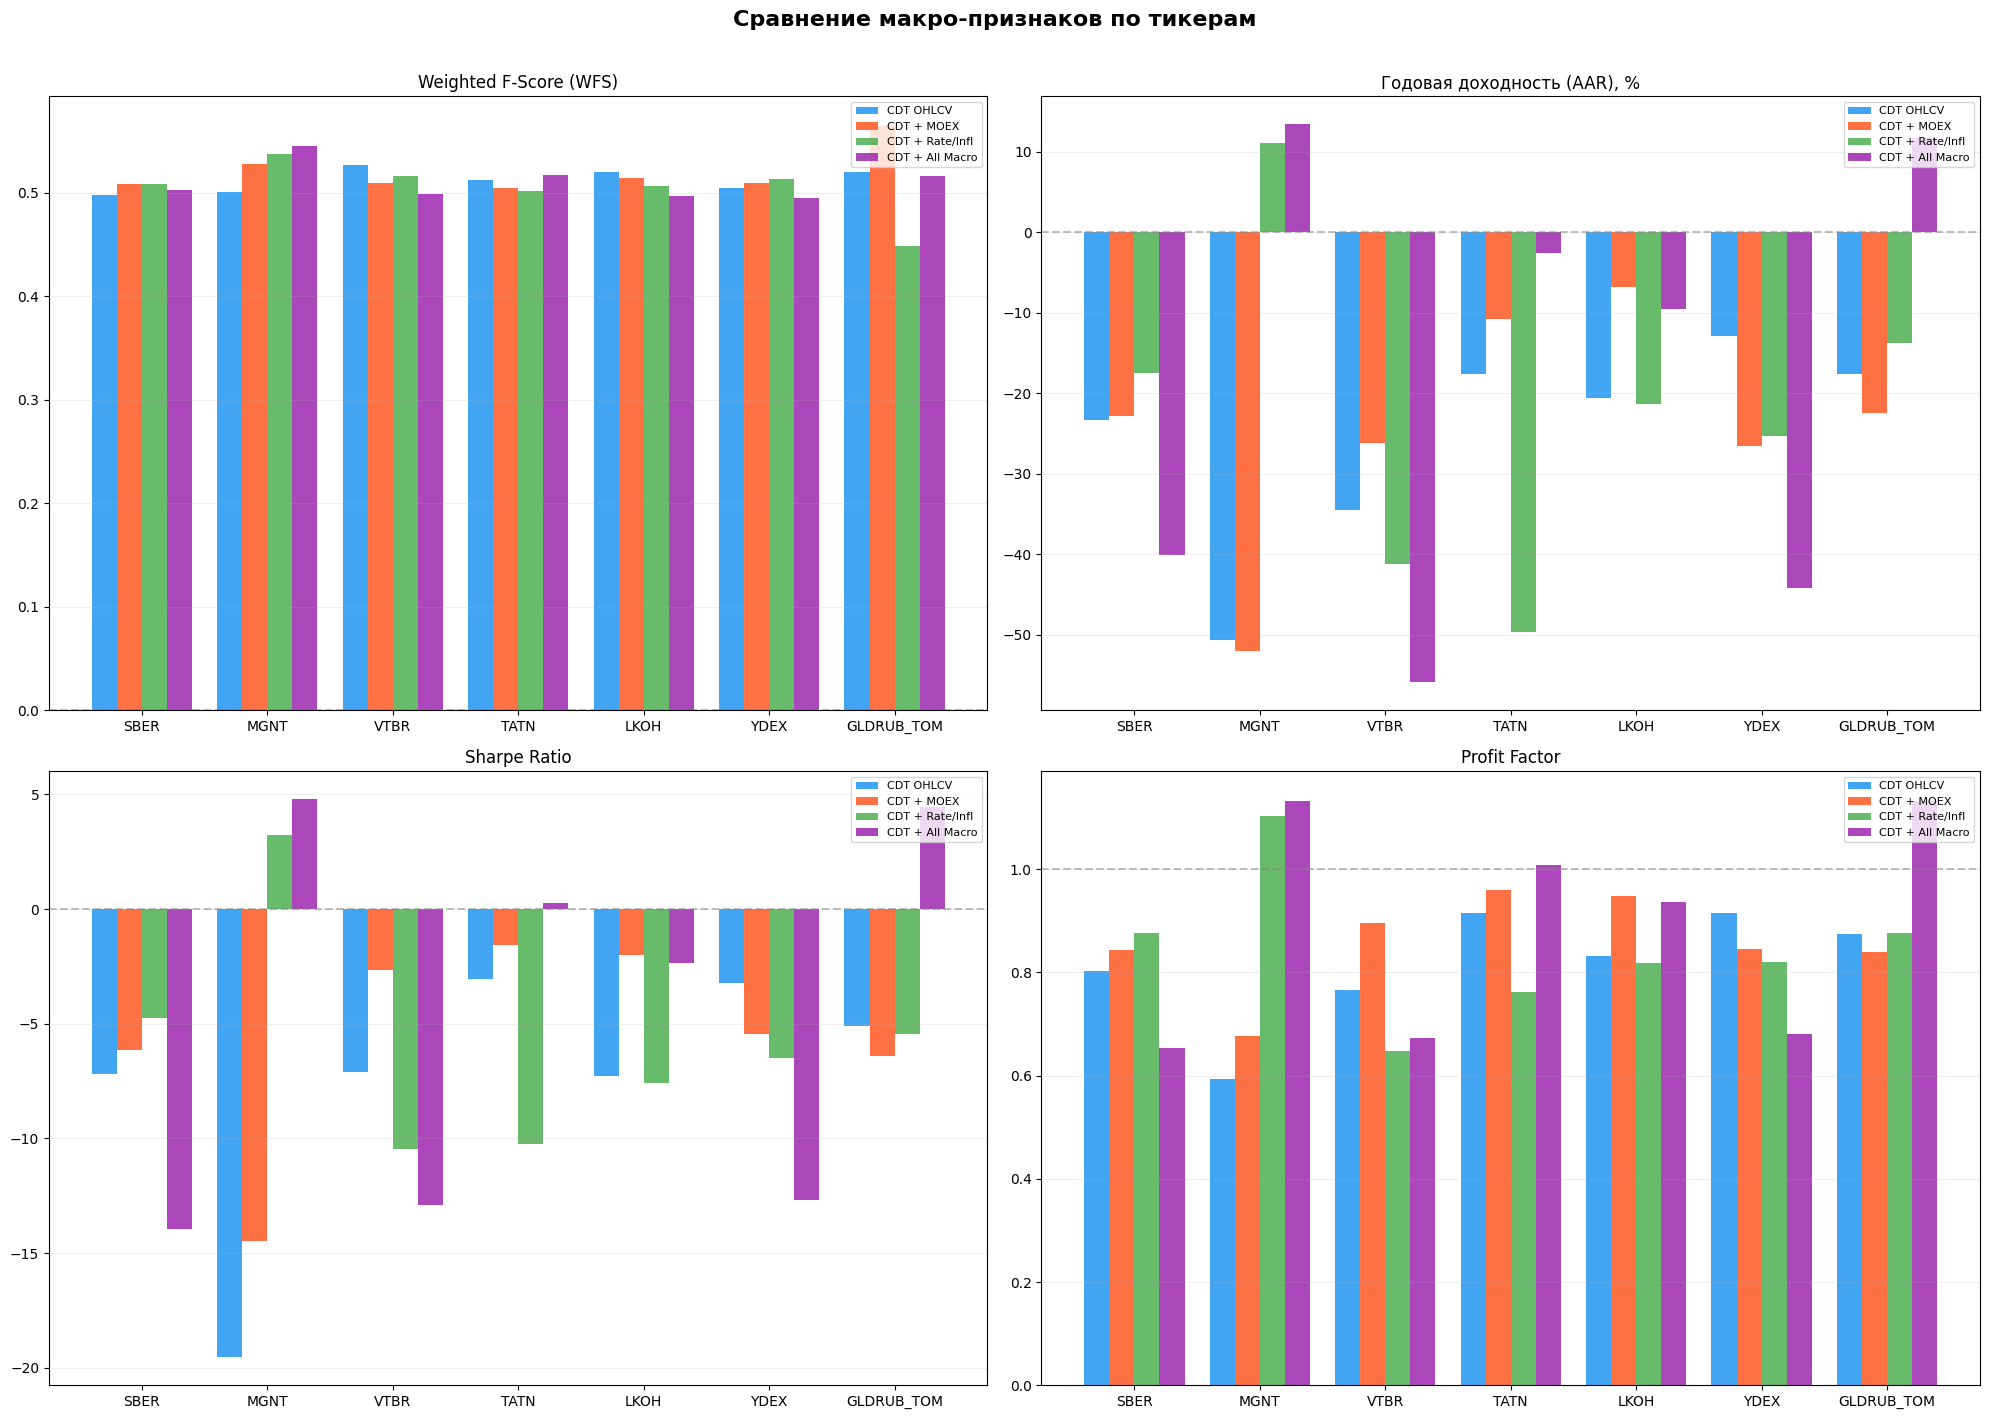

In [ ]:
base_features = ['Open', 'High', 'Low', 'Close', 'Volume']
moex_features = base_features + ['MOEX_Close', 'MOEX_Vol_20d', 'Relative_Strength']
rate_features = base_features + ['KeyRate', 'Inflation']
macro_features = base_features + ['MOEX_Close', 'MOEX_Vol_20d', 'Relative_Strength', 'KeyRate', 'Inflation']

EXPERIMENTS = [
    {"name": "CDT OHLCV", "features": base_features},
    {"name": "CDT + MOEX", "features": moex_features},
    {"name": "CDT + Rate/Infl", "features": rate_features},
    {"name": "CDT + All Macro", "features": macro_features},
]

all_results = []

for t in TICKERS:
    print(f"\n\n{'#'*100}")
    print(f"{'# ОБРАБОТКА ТИКЕРА: ' + t:^100}")
    print(f"{'#'*100}")

    file_path = os.path.join(DATA_DIR, f"{t}_5min.parquet")

    try:
        df_t = pd.read_parquet(file_path)
        df_t = df_t[(df_t['DateTime'] >= '2020-01-01') & (df_t['DateTime'] < '2026-01-01')]
        df_t = fill_time_gaps(df_t)
        df_t = clean_market_data(df_t)
        df_t_macro = add_macro_features(df_t, t)

        for exp in EXPERIMENTS:
            model_name = f"{exp['name']} ({t})"
            r = run_backtest(
                df_t_macro.copy(),
                exp['features'],
                build_cdt_1d_cnn,
                model_name
            )
            if r:
                r['ticker'] = t
                r['exp_name'] = exp['name']
                r['n_features'] = len(exp['features'])
                # r УЖЕ содержит 'wfs' и 'accuracy', спасибо run_backtest!
                all_results.append(r)

    except FileNotFoundError:
        print(f"⚠️ Файл для {t} не найден. Пропуск.")
    except Exception as e:
        print(f"❌ Критическая ошибка {t}: {e}")

# --- Печать таблицы ---
print(f"\n\n{'='*110}")
print(f"{'СВОДНАЯ ТАБЛИЦА — ВЛИЯНИЕ МАКРО-ПРИЗНАКОВ (ВСЕ ТИКЕРЫ)':^110}")
print(f"{'='*110}")
print(f"{'Модель':<35} {'Тикер':<6} {'Признаки':>4} {'WFS':>6} {'ACC':>6} {'AAR':>8} {'Sharpe':>8} {'PF':>6} {'WR':>6} {'Сделки':>7}")
print(f"{'-'*110}")

if all_results:
    for r in all_results:
        print(f"{r['model_name']:<35} {r['ticker']:<6} {r['n_features']:>4} {r['wfs']*100:>5.1f}% {r['accuracy']*100:>5.1f}% "
              f"{r['annual_return']:>7.1f}% {r['sharpe']:>8.2f} {r['profit_factor']:>5.2f} "
              f"{r['win_rate']:>5.1f}% {r['n_trades']:>7d}")
else:
    print("Нет результатов для отображения.")
print(f"{'='*110}")

# --- Отрисовка графиков ---
if all_results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()

    tickers_order = list(dict.fromkeys([r['ticker'] for r in all_results]))
    exp_order = [e['name'] for e in EXPERIMENTS]

    colors_map = {
        "CDT OHLCV": '#2196F3',
        "CDT + MOEX": '#FF5722',
        "CDT + Rate/Infl": '#4CAF50',
        "CDT + All Macro": '#9C27B0'
    }

    def plot_grouped_bars(ax, metric, title, baseline=0):
        data = {exp: [] for exp in exp_order}
        for t in tickers_order:
            for exp in exp_order:
                # Используем r.get(metric, 0) для безопасности
                val = next((r.get(metric, 0) for r in all_results if r['ticker']==t and r['exp_name']==exp), 0)
                data[exp].append(val)

        x = np.arange(len(tickers_order))
        width = 0.2
        multiplier = 0

        for exp_name, vals in data.items():
            offset = width * multiplier
            rects = ax.bar(x + offset, vals, width, label=exp_name, color=colors_map.get(exp_name, 'gray'), alpha=0.85)
            multiplier += 1

        ax.set_title(title, fontsize=12)
        ax.set_xticks(x + width * (len(exp_order) - 1) / 2)
        ax.set_xticklabels(tickers_order, fontsize=10)
        ax.axhline(baseline, color='gray', ls='--', alpha=0.5)
        ax.grid(alpha=0.2, axis='y')
        ax.legend(fontsize=8, loc='upper right')

    # Строим 4 графика, включая WFS
    plot_grouped_bars(axes[0], 'wfs', 'Weighted F-Score (WFS)', baseline=0)
    plot_grouped_bars(axes[1], 'annual_return', 'Годовая доходность (AAR), %', baseline=0)
    plot_grouped_bars(axes[2], 'sharpe', 'Sharpe Ratio', baseline=0)
    plot_grouped_bars(axes[3], 'profit_factor', 'Profit Factor', baseline=1)

    plt.suptitle('Сравнение макро-признаков по тикерам', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'macro_multi_ticker_comparison_{ALPHA}.png', dpi=150, bbox_inches='tight')
    plt.show()